# IMPORT & LIBRARY

Pada tahap ini dilakukan import library yang digunakan dalam penelitian, meliputi pustaka untuk pemodelan time series (SARIMA), neural network (MLPRegressor), preprocessing data (MinMaxScaler), evaluasi model (MAE, MSE, RMSE, R²), serta visualisasi data.





In [1]:
# ===============================
# Library utama
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualisasi
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Statistik time series
# ===============================
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===============================
# Machine Learning (AMBP)
# ===============================
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# Setting tampilan
# ===============================
plt.style.use('default')
sns.set_theme()

# DATA

Data curah hujan dibagi menjadi data training dan data aktual (testing). Setiap blok menggunakan skema rolling window selama 10 tahun untuk training dan 1 tahun berikutnya untuk pengujian, sehingga model dapat dievaluasi secara bertahap.

In [2]:
# ===============================
# Load dataset
# ===============================
df = pd.read_excel("CHNTBFIX.xlsx")

# Hapus kolom Unnamed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.tail()

,DATE,RAINFALL_MM
535,2025-08-01,11.26
536,2025-09-01,52.30
537,2025-10-01,76.20
538,2025-11-01,199.84
539,2025-12-01,246.83


In [3]:
# Ubah kolom DATE menjadi datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Urutkan berdasarkan tanggal
df = df.sort_values('DATE')

# Set DATE sebagai index
rain_series = df.set_index('DATE')['RAINFALL_MM']

# Paksa frekuensi bulanan awal bulan
rain_series = rain_series.asfreq('MS')

rain_series.head()

,RAINFALL_MM
DATE,
1981-01-01,370.93
1981-02-01,326.56
1981-03-01,219.61
1981-04-01,116.93
1981-05-01,127.20


In [4]:
print("Shape data:", rain_series.shape)
print("Tipe index:", type(rain_series.index))
print("Frekuensi:", rain_series.index.freq)
print("Periode data:",
      rain_series.index.min(),
      "sampai",
      rain_series.index.max())

Shape data: (540,)
Tipe index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frekuensi: <MonthBegin>
Periode data: 1981-01-01 00:00:00 sampai 2025-12-01 00:00:00


In [5]:
print("Jumlah missing value:", rain_series.isna().sum())
print("Jumlah nilai negatif:", (rain_series < 0).sum())
rain_series.describe()

Jumlah missing value: 0
Jumlah nilai negatif: 0


,RAINFALL_MM
count,540.000000
mean,108.293778
std,107.291980
min,0.180000
25%,9.387500
50%,80.570000
75%,181.645000
max,428.500000


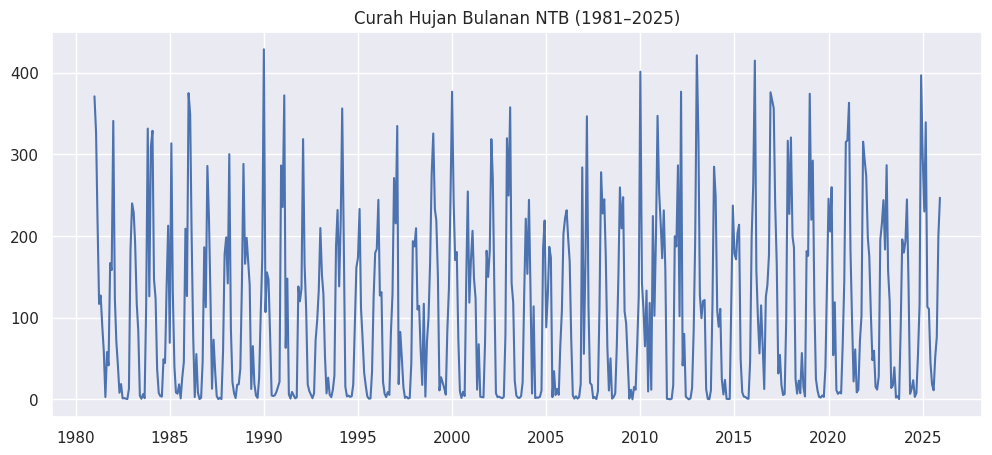

In [6]:
plt.figure(figsize=(12,5))
plt.plot(rain_series)
plt.title("Curah Hujan Bulanan NTB (1981–2025)")
plt.show()

# UJI ADF

Uji Augmented Dickey-Fuller (ADF) digunakan untuk menguji stasioneritas data time series. Hasil uji menunjukkan bahwa keputusan dilakukan berdasarkan nilai p-value dengan ambang batas 0.05. Jika data tidak stasioner, maka dilakukan differencing untuk memenuhi asumsi model SARIMA. Dalam penelitian ini digunakan differencing musiman (D=1) untuk menangkap pola tahunan pada data curah hujan.

In [7]:
from statsmodels.tsa.stattools import adfuller

print("=== ADF TEST DATA ASLI ===")
result = adfuller(rain_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data STASIONER")
else:
    print("Data TIDAK STASIONER → perlu differencing")

=== ADF TEST DATA ASLI ===
ADF Statistic: -5.671213078228454
p-value: 8.913329967612267e-07
Data STASIONER


# Seasonal Differencing
Melakukan differencing musiman (lag 12) untuk menghilangkan pola tahunan, kemudian diuji dengan ADF untuk memastikan data sudah stasioner sebelum digunakan pada model SARIMA.

In [8]:
rain_seasonal_diff = rain_series.diff(12).dropna()

print("\n=== ADF TEST SETELAH SEASONAL DIFFERENCING ===")
result2 = adfuller(rain_seasonal_diff)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])


=== ADF TEST SETELAH SEASONAL DIFFERENCING ===
ADF Statistic: -9.706533789177904
p-value: 1.0383068393511911e-16


# Identifikasi Parameter Model SARIMA (ACF dan PACF)

Pada tahap ini dilakukan analisis ACF (Autocorrelation Function) dan PACF (Partial Autocorrelation Function) terhadap data yang telah melalui seasonal differencing. Grafik ACF digunakan untuk mengidentifikasi komponen Moving Average (MA), sedangkan PACF digunakan untuk mengidentifikasi komponen Autoregressive (AR). Hasil analisis ini menjadi dasar dalam menentukan parameter model SARIMA yang optimal.

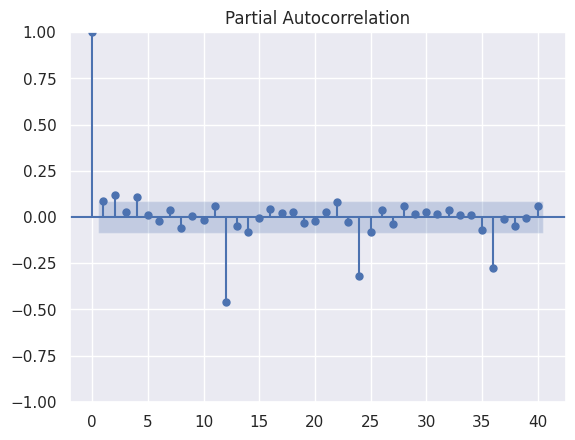

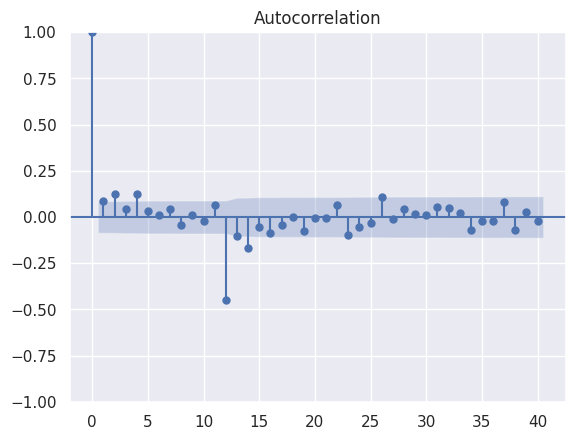

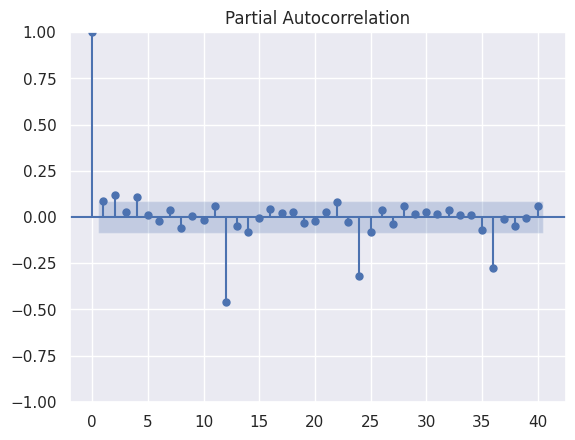

In [9]:
plot_acf(rain_seasonal_diff, lags=40)
plot_pacf(rain_seasonal_diff, lags=40)

# Pemilihan Model SARIMA Terbaik (Model Selection)
Pada tahap ini dilakukan evaluasi beberapa kandidat model SARIMA menggunakan data training dan testing. Data dibagi menjadi 80% training dan 20% testing. Setiap model dilatih, kemudian digunakan untuk memprediksi data testing.

Kinerja model dievaluasi menggunakan:

*   AIC dan BIC → untuk mengukur kompleksitas dan kecocokan model
*   RMSE dan MAE → untuk mengukur akurasi prediksi
*   Ljung-Box test → untuk memastikan residual tidak mengandung autokorelasi (model sudah baik)

Seluruh hasil disimpan dan diurutkan berdasarkan nilai AIC terendah untuk menentukan model terbaik.

In [10]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# ===============================
# SPLIT DATA
# ===============================
train_size = int(len(rain_series) * 0.8)
train = rain_series[:train_size]
test = rain_series[train_size:]

# ===============================
# KANDIDAT MODEL (FIX)
# ===============================
candidate_models = [
    ((0,0,1),(0,1,1,12)),
    ((1,0,1),(0,1,1,12)),
    ((2,0,1),(0,1,1,12)),
    ((1,0,2),(0,1,1,12)),
    ((2,0,2),(0,1,1,12)),

    ((0,0,1),(1,1,1,12)),
    ((1,0,1),(1,1,1,12)),
    ((2,0,1),(1,1,1,12)),

    ((1,1,1),(0,1,1,12)),
    ((2,1,1),(0,1,1,12)),
]

results = []

# ===============================
# LOOP EVALUASI
# ===============================
for order, seasonal_order in candidate_models:
    try:
        model = SARIMAX(train,
                        order=order,
                        seasonal_order=seasonal_order,
                        exog=None,
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        fitted = model.fit(disp=False)

        # Forecast
        forecast = fitted.forecast(steps=len(test))

        # Error metrics
        rmse = np.sqrt(np.mean((test - forecast)**2))
        mae = np.mean(np.abs(test - forecast))

        # Ljung-Box test
        lb_test = acorr_ljungbox(fitted.resid, lags=[12], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].values[0]

        results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'RMSE': rmse,
            'MAE': mae,
            'LjungBox_pvalue': lb_pvalue
        })

    except Exception as e:
        print(f"Model {order} {seasonal_order} gagal:", e)

# ===============================
# HASIL
# ===============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='AIC')

print(results_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


       order seasonal_order          AIC          BIC       RMSE        MAE  \
3  (1, 0, 2)  (0, 1, 1, 12)  4487.947149  4507.966585  59.164660  41.117297   
4  (2, 0, 2)  (0, 1, 1, 12)  4490.422115  4514.445438  59.400409  41.171473   
1  (1, 0, 1)  (0, 1, 1, 12)  4495.881276  4511.906688  60.260467  41.730429   
0  (0, 0, 1)  (0, 1, 1, 12)  4496.326712  4508.345771  60.270546  41.700232   
8  (1, 1, 1)  (0, 1, 1, 12)  4496.717468  4512.733016  57.124640  43.971914   
6  (1, 0, 1)  (1, 1, 1, 12)  4497.630691  4517.662457  60.322031  41.775180   
5  (0, 0, 1)  (1, 1, 1, 12)  4498.211835  4514.237248  60.292967  41.726548   
9  (2, 1, 1)  (0, 1, 1, 12)  4498.489615  4518.509050  57.065623  43.339791   
2  (2, 0, 1)  (0, 1, 1, 12)  4501.048702  4521.080468  59.376491  41.215709   
7  (2, 0, 1)  (1, 1, 1, 12)  4502.851502  4526.889621  59.381502  41.231177   

   LjungBox_pvalue  
3     3.894967e-01  
4     1.440897e-01  
1     1.329453e-12  
0     2.834853e-05  
8     2.915619e-01  
6   

In [11]:
valid_models = results_df[results_df['LjungBox_pvalue'] > 0.05]
valid_models = valid_models.sort_values(by='AIC')

print("\n=== MODEL VALID ===")
print(valid_models)


=== MODEL VALID ===
       order seasonal_order          AIC          BIC       RMSE        MAE  \
3  (1, 0, 2)  (0, 1, 1, 12)  4487.947149  4507.966585  59.164660  41.117297   
4  (2, 0, 2)  (0, 1, 1, 12)  4490.422115  4514.445438  59.400409  41.171473   
8  (1, 1, 1)  (0, 1, 1, 12)  4496.717468  4512.733016  57.124640  43.971914   
9  (2, 1, 1)  (0, 1, 1, 12)  4498.489615  4518.509050  57.065623  43.339791   
2  (2, 0, 1)  (0, 1, 1, 12)  4501.048702  4521.080468  59.376491  41.215709   
7  (2, 0, 1)  (1, 1, 1, 12)  4502.851502  4526.889621  59.381502  41.231177   

   LjungBox_pvalue  
3         0.389497  
4         0.144090  
8         0.291562  
9         0.288878  
2         0.430877  
7         0.494877  


In [12]:
valid_models = results_df[results_df['LjungBox_pvalue'] > 0.05]

In [13]:
# plot_acf(rain_series, lags=40)
# plt.show()

# plot_pacf(rain_series, lags=40)
# plt.show()

# Definisi block-based forecasting

In [14]:
# ===============================
# Definisi block-based forecasting
# ===============================
blocks = [
    ('1981-01-01','1990-12-01','1991-01-01','1991-12-01'),
    ('1986-01-01','1995-12-01','1996-01-01','1996-12-01'),
    ('1991-01-01','2000-12-01','2001-01-01','2001-12-01'),
    ('1996-01-01','2005-12-01','2006-01-01','2006-12-01'),
    ('2001-01-01','2010-12-01','2011-01-01','2011-12-01'),
    ('2006-01-01','2015-12-01','2016-01-01','2016-12-01'),
    ('2011-01-01','2020-12-01','2021-01-01','2021-12-01'),
    ('2016-01-01','2025-12-01','2026-01-01','2026-12-01')
]

# SARIMA


SARIMA BLOK 1
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 59.499823442443436
MSE  : 7952.562036620108
RMSE : 89.17713853124077
MAPE : 533.7277571704188
R2   : 0.3115877125062875

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
1991-01-01  254.144065
1991-02-01  222.488457
1991-03-01  171.731915
1991-04-01   90.386804
1991-05-01   45.602122
1991-06-01   29.650307
1991-07-01   12.119760
1991-08-01    4.465969
1991-09-01   17.054095
1991-10-01   37.276451
1991-11-01  137.103766
1991-12-01  184.527971

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
1991-01-01  235.49  254.144065
1991-02-01  372.08  222.488457
1991-03-01   63.19  171.731915
1991-04-01  147.90   90.386804
1991-05-01    6.26   45.602122
1991-06-01    1.11   29.650307
1991-07-01    9.20   12.119760
1991-08-01    5.31    4.465969
1991-09-01    1.34   17.054095
1991-10-01    2.69 

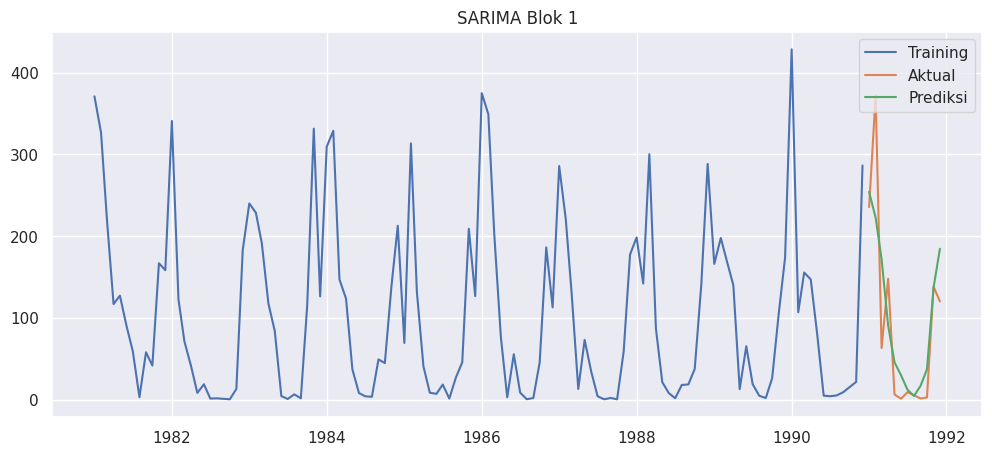


SARIMA BLOK 2
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 48.48272234364338
MSE  : 6351.070163041347
RMSE : 79.69360176978668
MAPE : 227.31654559698714
R2   : 0.3928801877823276

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
1996-01-01  220.131414
1996-02-01  217.856313
1996-03-01  178.102973
1996-04-01  103.653734
1996-05-01   27.127618
1996-06-01   22.648666
1996-07-01    6.712783
1996-08-01    4.267738
1996-09-01    5.969045
1996-10-01   28.121324
1996-11-01  114.999350
1996-12-01  186.457412

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
1996-01-01  184.10  220.131414
1996-02-01  244.27  217.856313
1996-03-01  127.13  178.102973
1996-04-01  131.29  103.653734
1996-05-01   21.51   27.127618
1996-06-01    6.90   22.648666
1996-07-01    2.86    6.712783
1996-08-01    8.96    4.267738
1996-09-01    5.58    5.969045
1996-10-01   81.41 

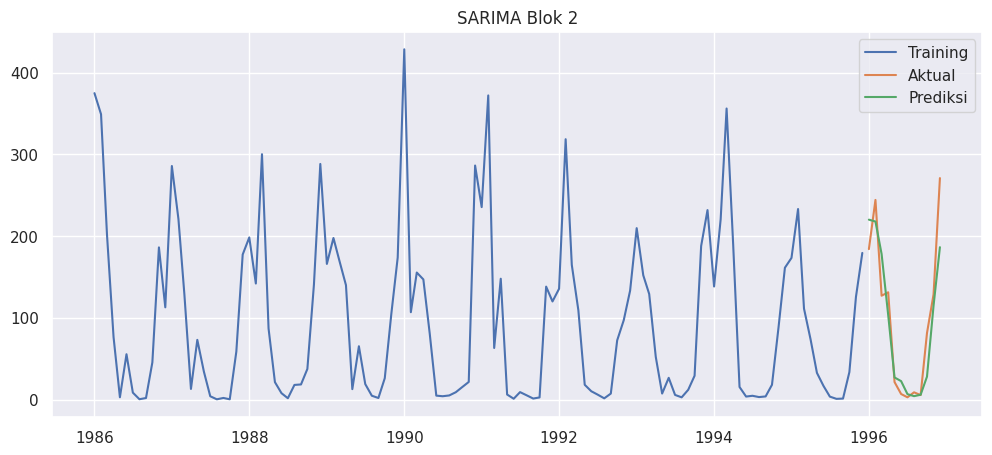


SARIMA BLOK 3
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 43.128440377188674
MSE  : 5096.078314442364
RMSE : 71.38682171411166
MAPE : 108.18637773617597
R2   : 0.48239965706413546

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
2001-01-01  239.336630
2001-02-01  242.165654
2001-03-01  151.468821
2001-04-01  135.900887
2001-05-01   41.311520
2001-06-01   15.199240
2001-07-01   22.983556
2001-08-01    7.242803
2001-09-01   14.089441
2001-10-01   81.084391
2001-11-01  158.489737
2001-12-01  196.948180

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2001-01-01  170.44  239.336630
2001-02-01  206.45  242.165654
2001-03-01  148.22  151.468821
2001-04-01  123.70  135.900887
2001-05-01   12.01   41.311520
2001-06-01   67.58   15.199240
2001-07-01    3.32   22.983556
2001-08-01    2.96    7.242803
2001-09-01    2.55   14.089441
2001-10-01   67.9

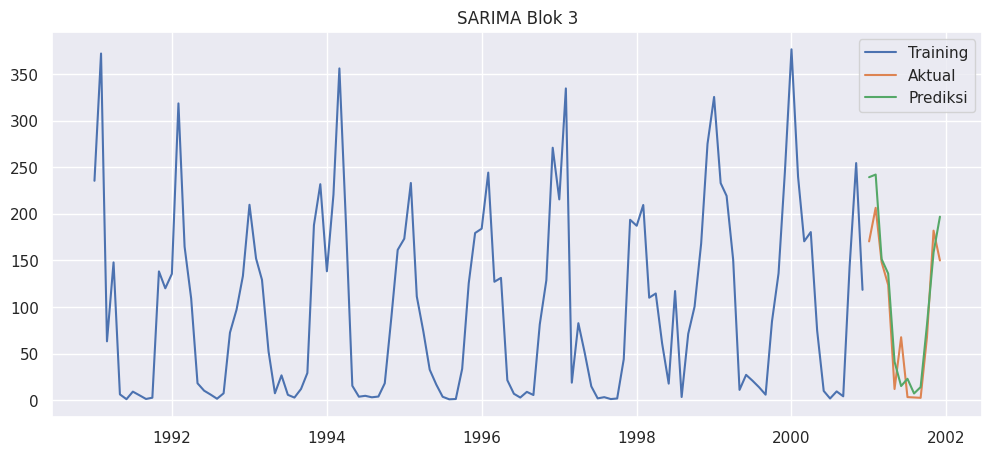


SARIMA BLOK 4
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 49.08347499063118
MSE  : 4973.856561167991
RMSE : 70.52557380956209
MAPE : 233.84280773864057
R2   : 0.502362264719821

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
2006-01-01  214.681009
2006-02-01  252.249252
2006-03-01  152.943782
2006-04-01  121.354632
2006-05-01   37.826819
2006-06-01   18.821651
2006-07-01   16.145429
2006-08-01    6.138779
2006-09-01   10.518647
2006-10-01   57.990882
2006-11-01  141.522605
2006-12-01  221.571655

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2006-01-01  221.73  214.681009
2006-02-01  231.51  252.249252
2006-03-01  198.98  152.943782
2006-04-01  168.91  121.354632
2006-05-01   73.56   37.826819
2006-06-01    4.75   18.821651
2006-07-01    1.09   16.145429
2006-08-01    3.87    6.138779
2006-09-01    1.07   10.518647
2006-10-01    2.91  

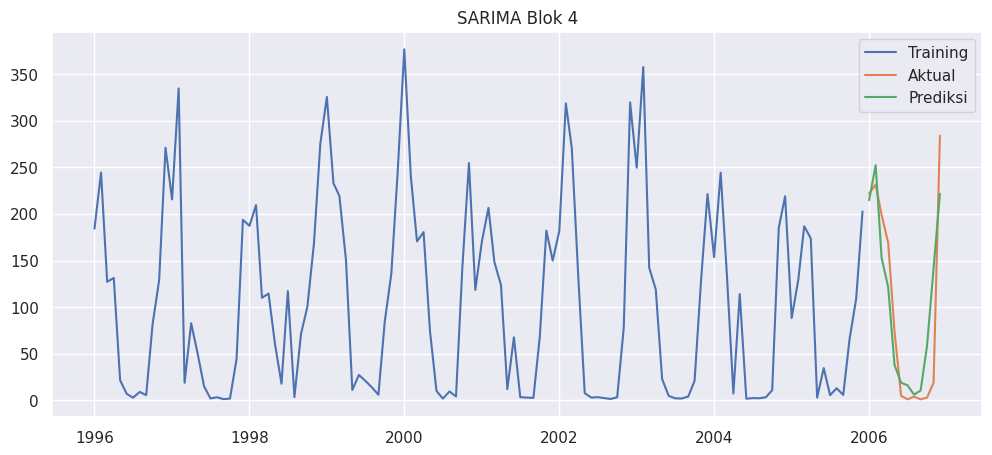


SARIMA BLOK 5
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 49.870748255439025
MSE  : 5437.003775792012
RMSE : 73.73604122674347
MAPE : 191.42933529679675
R2   : 0.479359267677973

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
2011-01-01  215.034148
2011-02-01  222.766764
2011-03-01  176.643996
2011-04-01  101.204436
2011-05-01   51.009600
2011-06-01   18.463311
2011-07-01   22.317238
2011-08-01    4.780267
2011-09-01   40.603207
2011-10-01   40.222854
2011-11-01  125.623096
2011-12-01  245.224777

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2011-01-01  252.99  215.034148
2011-02-01  214.05  222.766764
2011-03-01  172.84  176.643996
2011-04-01  231.43  101.204436
2011-05-01  159.05   51.009600
2011-06-01    0.75   18.463311
2011-07-01    0.65   22.317238
2011-08-01    0.18    4.780267
2011-09-01    0.96   40.603207
2011-10-01   17.23 

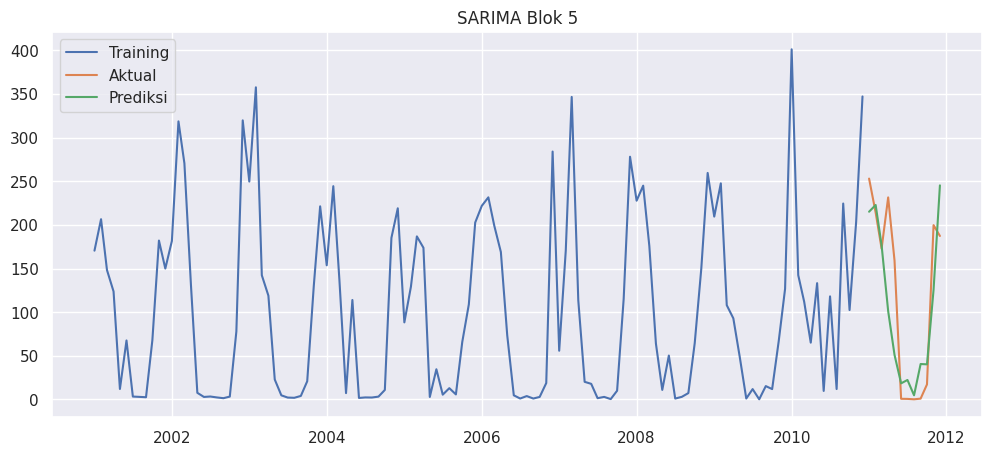


SARIMA BLOK 6
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 57.50944157095511
MSE  : 7114.455815018895
RMSE : 84.34723359434437
MAPE : 499.44177100480294
R2   : 0.3815004492639896

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
2016-01-01  253.338624
2016-02-01  191.267497
2016-03-01  191.080080
2016-04-01  120.143234
2016-05-01   72.111548
2016-06-01   22.463147
2016-07-01   17.596238
2016-08-01    2.680393
2016-09-01   25.315596
2016-10-01   23.509883
2016-11-01  112.080947
2016-12-01  240.143804

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2016-01-01  264.52  253.338624
2016-02-01  414.64  191.267497
2016-03-01  158.53  191.080080
2016-04-01   98.26  120.143234
2016-05-01   56.35   72.111548
2016-06-01  115.15   22.463147
2016-07-01   66.79   17.596238
2016-08-01   12.76    2.680393
2016-09-01  125.35   25.315596
2016-10-01  139.74 

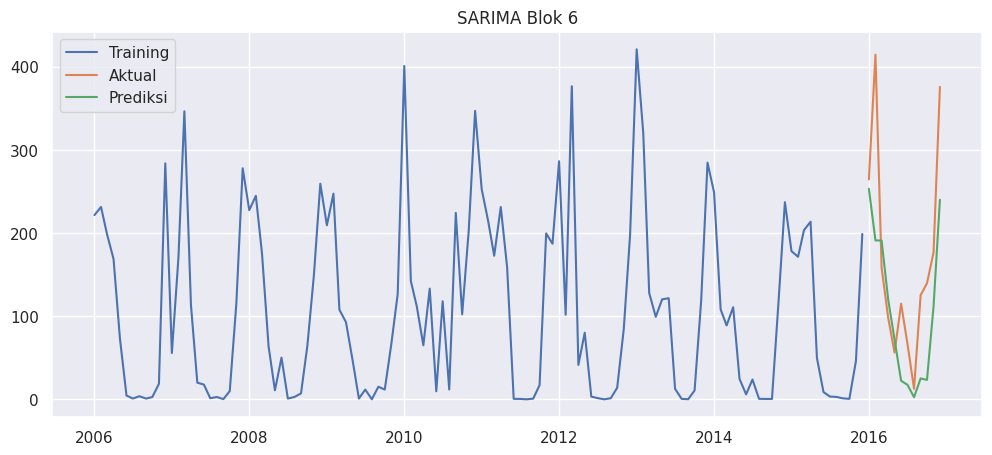


SARIMA BLOK 7
Jumlah data training: (120,)
Jumlah data aktual: (12,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 58.728393230090305
MSE  : 7566.608730629496
RMSE : 86.98625598696323
MAPE : 139.99234661335817
R2   : 0.4338517270811957

=== HASIL PREDIKSI 12 BULAN ===
              PREDIKSI
DATE                  
2021-01-01  312.155597
2021-02-01  232.328876
2021-03-01  210.636419
2021-04-01  115.573674
2021-05-01   67.333753
2021-06-01   35.590367
2021-07-01   14.463220
2021-08-01    9.114555
2021-09-01   16.358874
2021-10-01   35.158625
2021-11-01  142.458818
2021-12-01  234.262239

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2021-01-01  317.18  312.155597
2021-02-01  362.96  232.328876
2021-03-01  183.83  210.636419
2021-04-01   96.28  115.573674
2021-05-01   22.04   67.333753
2021-06-01   61.22   35.590367
2021-07-01    8.63   14.463220
2021-08-01   11.91    9.114555
2021-09-01   72.10   16.358874
2021-10-01  101.73

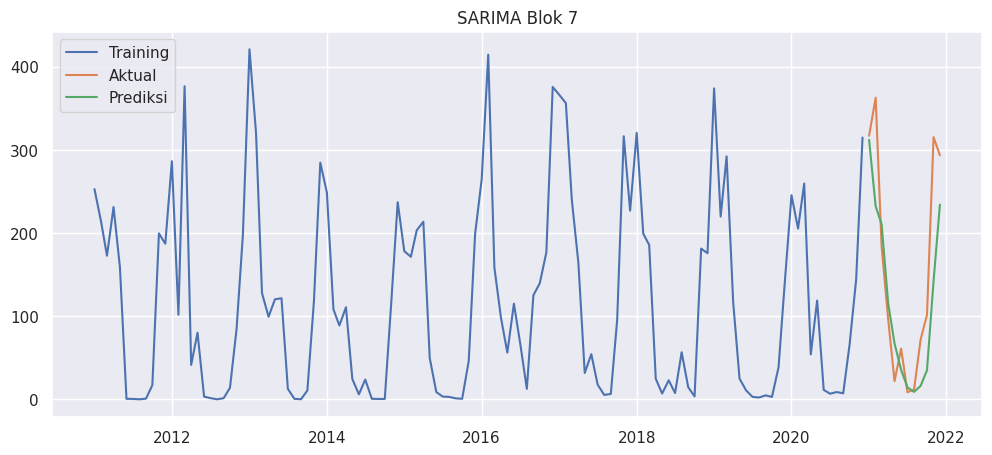


SARIMA BLOK 8
Jumlah data training: (120,)
Jumlah data aktual: (0,)

Training selesai

=== ERROR TRAINING BLOK ===
MAE  : 61.14511971916766
MSE  : 8065.871087906684
RMSE : 89.81019478826823
MAPE : 305.40756907305774
R2   : 0.39992087002094856

=== BLOK TANPA DATA AKTUAL (FORECAST ONLY) ===

=== HASIL PREDIKSI ===
              PREDIKSI
2026-01-01  281.043465
2026-02-01  249.169584
2026-03-01  223.774756
2026-04-01  103.389067
2026-05-01   44.101941
2026-06-01   41.060256
2026-07-01   20.767596
2026-08-01   12.678838
2026-09-01   32.343079
2026-10-01   73.660888
2026-11-01  179.319978
2026-12-01  261.277262


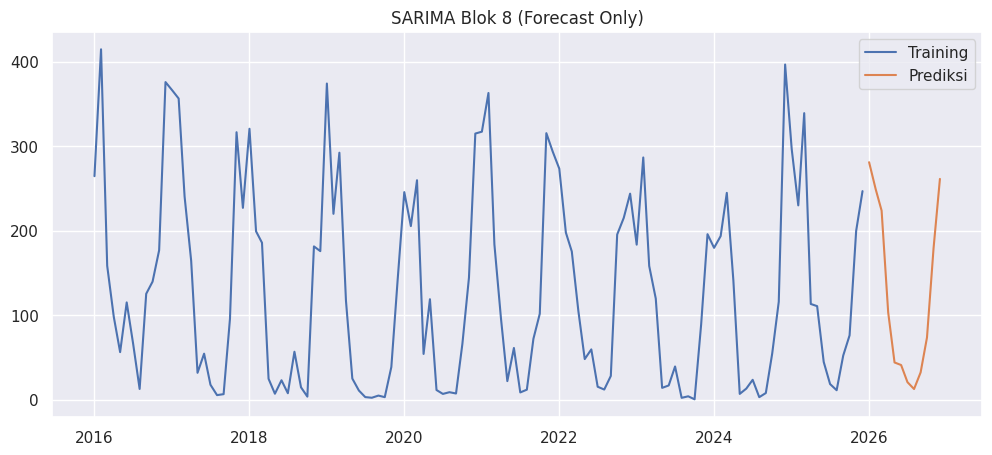

In [15]:
# ===============================
# SARIMA BLOCK-BASED (FULL LOOP)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sarima_results = []

# ===============================
# LOOP BLOCK-BASED FORECASTING
# ===============================
for i, (train_start, train_end, test_start, test_end) in enumerate(blocks):

    print(f"\n===============================")
    print(f"SARIMA BLOK {i+1}")
    print(f"===============================")

    # ===============================
    # DATA TRAINING & AKTUAL
    # ===============================
    train_block = rain_series.loc[train_start:train_end]
    actual = rain_series.loc[test_start:test_end]

    print("Jumlah data training:", train_block.shape)
    print("Jumlah data aktual:", actual.shape)

    # ===============================
    # DEFINISI MODEL (FIX)
    # ===============================
    order = (0,0,1)
    seasonal_order = (0,1,1,12)

    # ===============================
    # TRAINING
    # ===============================
    model = SARIMAX(
        train_block,
        order=order,
        seasonal_order=seasonal_order,
        exog=None,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)

    print("\nTraining selesai")

    # ===============================
    # ERROR TRAINING
    # ===============================
    train_pred = results.predict(
        start=train_block.index[0],
        end=train_block.index[-1]
    )

    mae_train = mean_absolute_error(train_block, train_pred)
    mse_train = mean_squared_error(train_block, train_pred)
    rmse_train = np.sqrt(mse_train)
    mape_train = np.mean(np.abs((train_block - train_pred) / train_block)) * 100
    r2_train = r2_score(train_block, train_pred)

    print("\n=== ERROR TRAINING BLOK ===")
    print("MAE  :", mae_train)
    print("MSE  :", mse_train)
    print("RMSE :", rmse_train)
    print("MAPE :", mape_train)
    print("R2   :", r2_train)

    # ===============================
    # PREDIKSI (HANDLE BLOK 8)
    # ===============================
    if len(actual) == 0:

        print("\n=== BLOK TANPA DATA AKTUAL (FORECAST ONLY) ===")

        forecast = results.forecast(steps=12)

        # buat index manual (2026)
        forecast_index = pd.date_range(start=test_start, periods=12, freq='MS')
        forecast.index = forecast_index

        forecast_df = pd.DataFrame({
            'PREDIKSI': forecast
        })

        sarima_forecast_2026 = forecast.copy()

        print("\n=== HASIL PREDIKSI ===")
        print(forecast_df)

        # simpan tanpa error prediksi
        sarima_results.append({
            "block": i+1,
            "MAE_Train": mae_train,
            "MSE_Train": mse_train,
            "RMSE_Train": rmse_train,
            "MAPE_Train": mape_train,
            "R2_Train": r2_train,
            "MAE_Pred": None,
            "MSE_Pred": None,
            "RMSE_Pred": None,
            "MAPE_Pred": None,
            "R2_Pred": None
        })

        # plot tanpa aktual
        plt.figure(figsize=(12,5))
        plt.plot(train_block, label='Training')
        plt.plot(forecast, label='Prediksi')
        plt.legend()
        plt.title(f"SARIMA Blok {i+1} (Forecast Only)")
        plt.show()

    else:
        # ===============================
        # PREDIKSI NORMAL
        # ===============================
        forecast = results.forecast(steps=12)
        forecast.index = actual.index

        forecast_df = pd.DataFrame({
            'PREDIKSI': forecast
        })

        print("\n=== HASIL PREDIKSI 12 BULAN ===")
        print(forecast_df)

        # ===============================
        # AKTUAL VS PREDIKSI
        # ===============================
        comparison = pd.DataFrame({
            'AKTUAL': actual,
            'PREDIKSI': forecast
        })

        print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
        print(comparison)

        # ===============================
        # ERROR PREDIKSI
        # ===============================
        mae_pred = mean_absolute_error(actual, forecast)
        mse_pred = mean_squared_error(actual, forecast)
        rmse_pred = np.sqrt(mse_pred)
        mape_pred = np.mean(np.abs((actual - forecast) / actual)) * 100
        r2_pred = r2_score(actual, forecast)

        print("\n=== ERROR PREDIKSI ===")
        print("MAE  :", mae_pred)
        print("MSE  :", mse_pred)
        print("RMSE :", rmse_pred)
        print("MAPE :", mape_pred)
        print("R2   :", r2_pred)

        # ===============================
        # SIMPAN HASIL
        # ===============================
        sarima_results.append({
            "block": i+1,
            "MAE_Train": mae_train,
            "MSE_Train": mse_train,
            "RMSE_Train": rmse_train,
            "MAPE_Train": mape_train,
            "R2_Train": r2_train,
            "MAE_Pred": mae_pred,
            "MSE_Pred": mse_pred,
            "RMSE_Pred": rmse_pred,
            "MAPE_Pred": mape_pred,
            "R2_Pred": r2_pred
        })

        # ===============================
        # PLOT
        # ===============================
        plt.figure(figsize=(12,5))
        plt.plot(train_block, label='Training')
        plt.plot(actual, label='Aktual')
        plt.plot(forecast, label='Prediksi')
        plt.legend()
        plt.title(f"SARIMA Blok {i+1}")
        plt.show()

# AMBP MODELING



In [16]:
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

In [17]:
# ===============================
# AMBP MODEL SELECTION
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Gunakan data training awal (blok 1 saja dulu)
train_data = rain_series['1981-01-01':'1990-12-01']

# Scaling
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.values.reshape(-1,1))

# Split internal (untuk validasi)
split = int(len(train_scaled)*0.8)
train_part = train_scaled[:split]
val_part = train_scaled[split:]

# Kandidat parameter
lags = [6, 12]
neurons = [(10,), (20,), (20,10)]
activations = ['relu', 'tanh']

results = []

for lag in lags:
    # Buat lagged data
    X_train, y_train = create_lagged_data(train_part, lag)
    X_val, y_val = create_lagged_data(val_part, lag)

    for neuron in neurons:
        for act in activations:
            try:
                model = MLPRegressor(
                    hidden_layer_sizes=neuron,
                    activation=act,
                    solver='adam',
                    max_iter=2000,
                    early_stopping=True,
                    random_state=42
                )

                model.fit(X_train, y_train.ravel())

                pred_val = model.predict(X_val)

                rmse = np.sqrt(mean_squared_error(y_val, pred_val))

                results.append({
                    'lag': lag,
                    'neuron': neuron,
                    'activation': act,
                    'RMSE': rmse
                })

            except:
                pass

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='RMSE')

print(results_df)

    lag    neuron activation      RMSE
2     6     (20,)       relu  0.185611
3     6     (20,)       tanh  0.196226
1     6     (10,)       tanh  0.208680
4     6  (20, 10)       relu  0.223926
6    12     (10,)       relu  0.227637
10   12  (20, 10)       relu  0.230077
0     6     (10,)       relu  0.232952
9    12     (20,)       tanh  0.233151
7    12     (10,)       tanh  0.236645
5     6  (20, 10)       tanh  0.247905
11   12  (20, 10)       tanh  0.264286
8    12     (20,)       relu  0.283625


In [18]:
best_config = results_df.iloc[0]

best_lag = int(best_config['lag'])
best_neuron = best_config['neuron']
best_activation = best_config['activation']

print("\n=== BEST AMBP CONFIG ===")
print(best_config)


=== BEST AMBP CONFIG ===
lag                  6
neuron           (20,)
activation        relu
RMSE          0.185611
Name: 2, dtype: object


# AMBP


AMBP BLOK 1
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 402

=== ERROR TRAINING BLOK ===
MAE : 39.99958202438908
MSE : 3701.2968452355544
RMSE: 60.83828437123744
R2  : 0.6732258064662442

=== HASIL PREDIKSI 12 BULAN ===
DATE
1991-01-01    158.240635
1991-02-01    183.393650
1991-03-01    127.588392
1991-04-01     94.642757
1991-05-01     36.156207
1991-06-01     13.866968
1991-07-01      8.803195
1991-08-01      7.565777
1991-09-01      5.532882
1991-10-01     10.441953
1991-11-01     24.569769
1991-12-01    158.053085
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
1991-01-01  235.49  158.240635
1991-02-01  372.08  183.393650
1991-03-01   63.19  127.588392
1991-04-01  147.90   94.642757
1991-05-01    6.26   36.156207
1991-06-01    1.11   13.866968
1991-07-01    9.20    8.803195
1991-08-01    5.31    7.565777
1991-09-01    1.34    5.532882
199

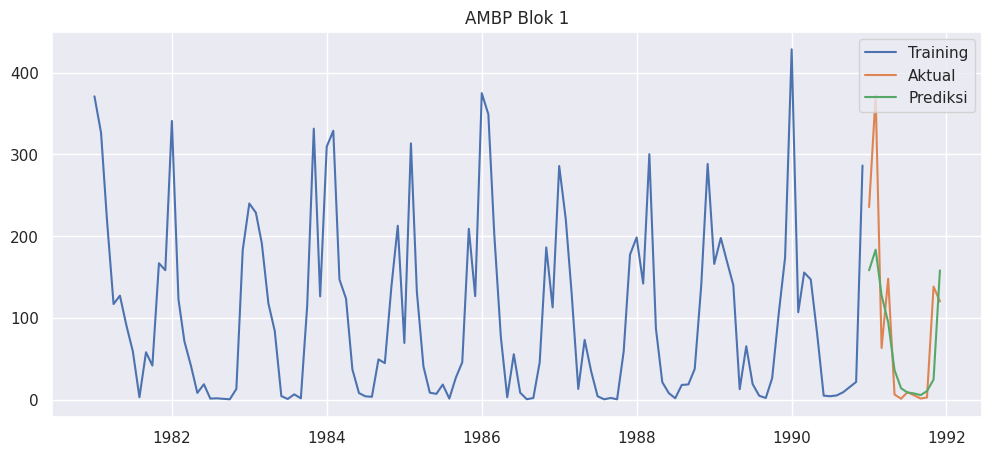


AMBP BLOK 2
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 546

=== ERROR TRAINING BLOK ===
MAE : 34.81615179158694
MSE : 2790.5445879228355
RMSE: 52.8256054193687
R2  : 0.7140551571603755

=== HASIL PREDIKSI 12 BULAN ===
DATE
1996-01-01    195.121892
1996-02-01    222.009925
1996-03-01    195.928706
1996-04-01     78.248839
1996-05-01     19.495103
1996-06-01      9.689076
1996-07-01      4.266655
1996-08-01      2.321272
1996-09-01      6.504471
1996-10-01     28.375325
1996-11-01    117.652570
1996-12-01    220.625299
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
1996-01-01  184.10  195.121892
1996-02-01  244.27  222.009925
1996-03-01  127.13  195.928706
1996-04-01  131.29   78.248839
1996-05-01   21.51   19.495103
1996-06-01    6.90    9.689076
1996-07-01    2.86    4.266655
1996-08-01    8.96    2.321272
1996-09-01    5.58    6.504471
1996

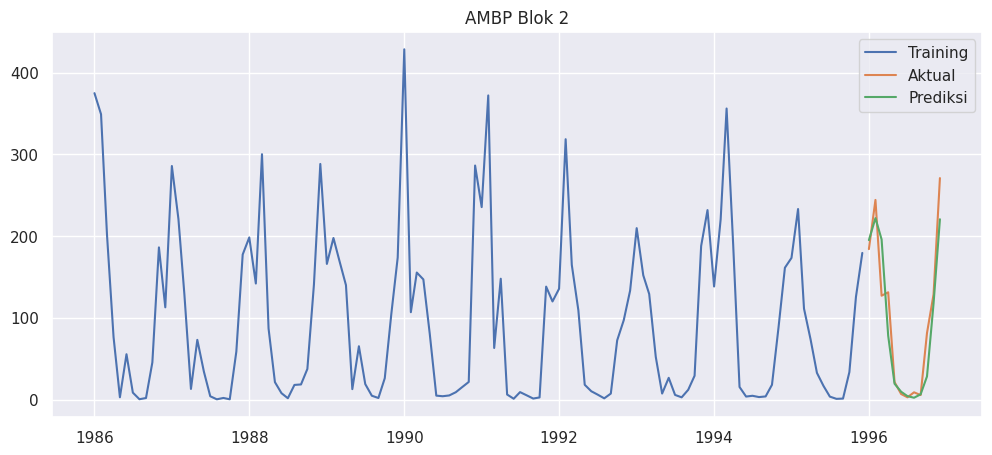


AMBP BLOK 3
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 171

=== ERROR TRAINING BLOK ===
MAE : 51.52706805272193
MSE : 6986.737735875814
RMSE: 83.58670788992598
R2  : 0.2662294289700641

=== HASIL PREDIKSI 12 BULAN ===
DATE
2001-01-01    236.778623
2001-02-01    124.807387
2001-03-01     48.415355
2001-04-01     30.354729
2001-05-01     14.415089
2001-06-01     19.923424
2001-07-01     11.901060
2001-08-01     22.474294
2001-09-01     27.648647
2001-10-01     73.809661
2001-11-01    166.775511
2001-12-01    145.772921
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2001-01-01  170.44  236.778623
2001-02-01  206.45  124.807387
2001-03-01  148.22   48.415355
2001-04-01  123.70   30.354729
2001-05-01   12.01   14.415089
2001-06-01   67.58   19.923424
2001-07-01    3.32   11.901060
2001-08-01    2.96   22.474294
2001-09-01    2.55   27.648647
2001

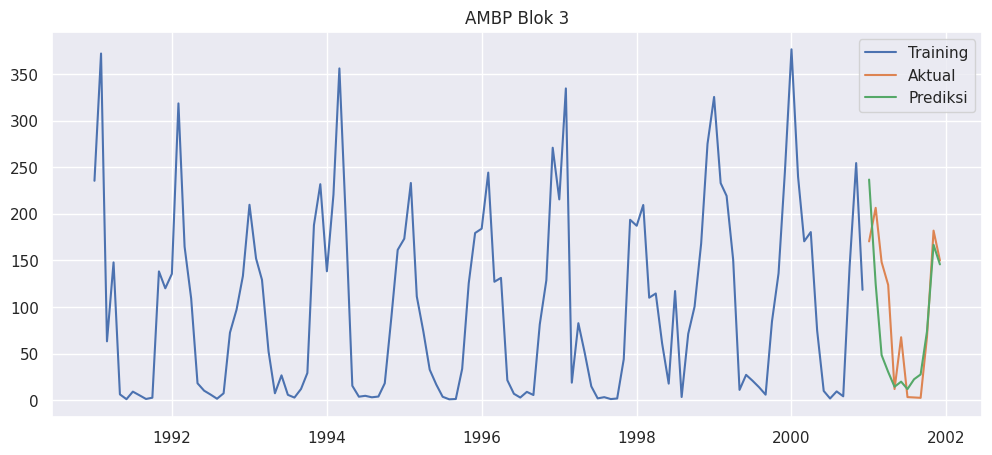


AMBP BLOK 4
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 426

=== ERROR TRAINING BLOK ===
MAE : 38.690297267239195
MSE : 2971.969772104507
RMSE: 54.515775442568064
R2  : 0.7076247649327435

=== HASIL PREDIKSI 12 BULAN ===
DATE
2006-01-01    175.376356
2006-02-01    164.417378
2006-03-01     71.525243
2006-04-01     70.012806
2006-05-01     14.419465
2006-06-01     11.253826
2006-07-01      5.613280
2006-08-01     10.452634
2006-09-01     10.991938
2006-10-01     78.659014
2006-11-01    164.838217
2006-12-01    132.223449
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2006-01-01  221.73  175.376356
2006-02-01  231.51  164.417378
2006-03-01  198.98   71.525243
2006-04-01  168.91   70.012806
2006-05-01   73.56   14.419465
2006-06-01    4.75   11.253826
2006-07-01    1.09    5.613280
2006-08-01    3.87   10.452634
2006-09-01    1.07   10.991938
20

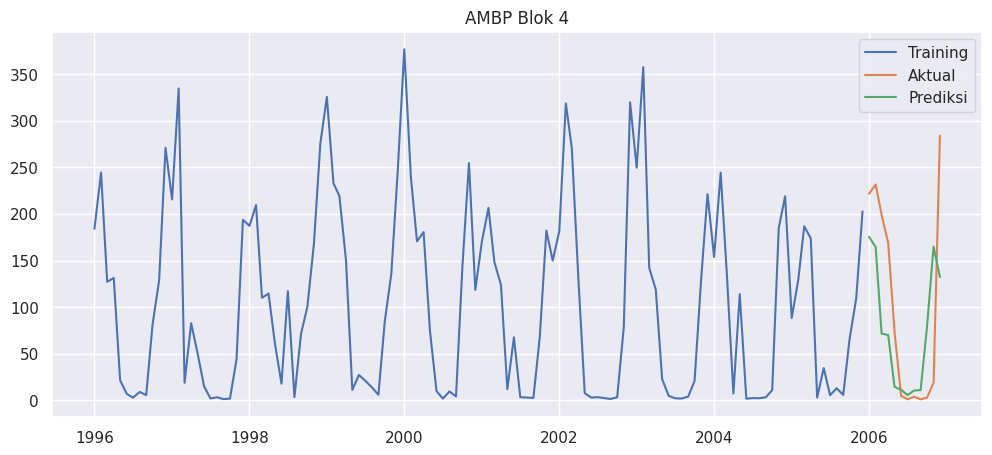


AMBP BLOK 5
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 175

=== ERROR TRAINING BLOK ===
MAE : 48.992753955157255
MSE : 5933.006373571341
RMSE: 77.02601101946888
R2  : 0.45986085382026576

=== HASIL PREDIKSI 12 BULAN ===
DATE
2011-01-01    196.004682
2011-02-01     48.311845
2011-03-01     25.233061
2011-04-01      6.622605
2011-05-01     12.837158
2011-06-01      5.962889
2011-07-01     25.157376
2011-08-01     27.140276
2011-09-01    171.190302
2011-10-01    204.248328
2011-11-01    221.499165
2011-12-01    122.937673
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2011-01-01  252.99  196.004682
2011-02-01  214.05   48.311845
2011-03-01  172.84   25.233061
2011-04-01  231.43    6.622605
2011-05-01  159.05   12.837158
2011-06-01    0.75    5.962889
2011-07-01    0.65   25.157376
2011-08-01    0.18   27.140276
2011-09-01    0.96  171.190302
20

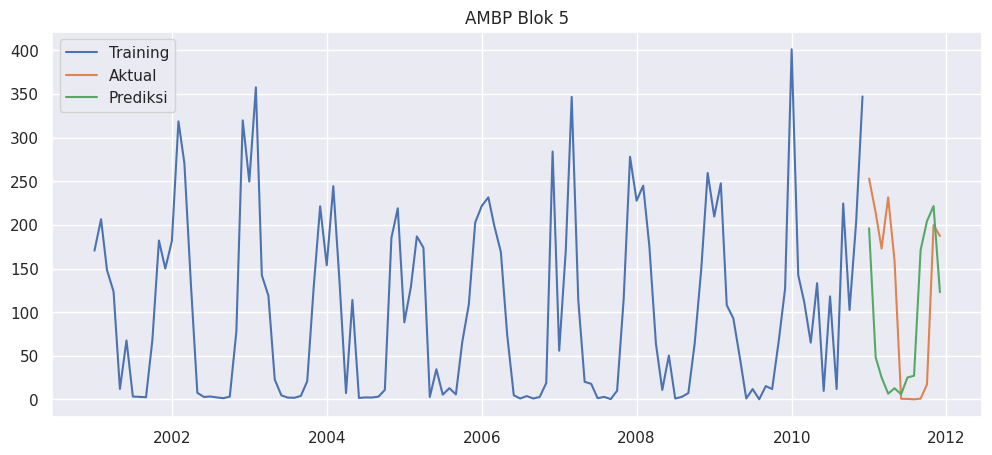


AMBP BLOK 6
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 258

=== ERROR TRAINING BLOK ===
MAE : 46.76534812879246
MSE : 5001.259414436561
RMSE: 70.71958296282976
R2  : 0.5661160501353756

=== HASIL PREDIKSI 12 BULAN ===
DATE
2016-01-01    279.030929
2016-02-01    170.638289
2016-03-01    263.679705
2016-04-01    166.175088
2016-05-01     68.549422
2016-06-01     19.207881
2016-07-01     11.329864
2016-08-01      5.148801
2016-09-01      2.703927
2016-10-01      3.658800
2016-11-01     46.905683
2016-12-01    150.187414
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2016-01-01  264.52  279.030929
2016-02-01  414.64  170.638289
2016-03-01  158.53  263.679705
2016-04-01   98.26  166.175088
2016-05-01   56.35   68.549422
2016-06-01  115.15   19.207881
2016-07-01   66.79   11.329864
2016-08-01   12.76    5.148801
2016-09-01  125.35    2.703927
2016

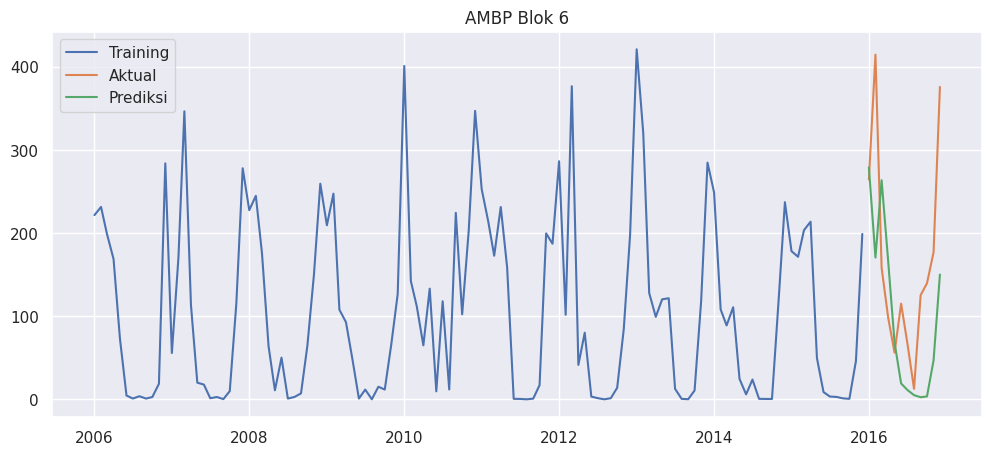


AMBP BLOK 7
Training size: (120,)
Actual size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 180

=== ERROR TRAINING BLOK ===
MAE : 52.93378247706001
MSE : 5430.041573241482
RMSE: 73.68881579481028
R2  : 0.6042985476906784

=== HASIL PREDIKSI 12 BULAN ===
DATE
2021-01-01    433.132335
2021-02-01    203.251317
2021-03-01    189.691520
2021-04-01     40.022163
2021-05-01     34.246856
2021-06-01     18.769877
2021-07-01      7.610001
2021-08-01     13.824915
2021-09-01     15.615442
2021-10-01     50.318350
2021-11-01    140.535842
2021-12-01    213.106050
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL    PREDIKSI
DATE                          
2021-01-01  317.18  433.132335
2021-02-01  362.96  203.251317
2021-03-01  183.83  189.691520
2021-04-01   96.28   40.022163
2021-05-01   22.04   34.246856
2021-06-01   61.22   18.769877
2021-07-01    8.63    7.610001
2021-08-01   11.91   13.824915
2021-09-01   72.10   15.615442
2021

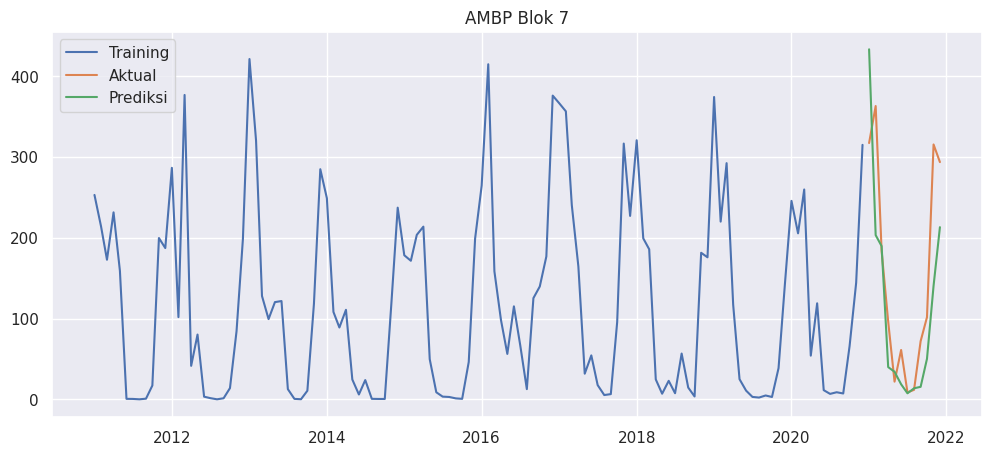


AMBP BLOK 8
Training size: (120,)
Actual size: (0,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 439

=== ERROR TRAINING BLOK ===
MAE : 43.38754690866963
MSE : 3702.1305737305415
RMSE: 60.84513599073094
R2  : 0.7189207563853448

=== BLOK TANPA DATA AKTUAL (FORECAST ONLY) ===

=== HASIL PREDIKSI ===
2026-01-01    288.366456
2026-02-01    308.969006
2026-03-01    158.055044
2026-04-01     52.822521
2026-05-01     29.136434
2026-06-01     18.992374
2026-07-01     12.888240
2026-08-01     11.007929
2026-09-01     24.780105
2026-10-01     66.201490
2026-11-01    220.207599
2026-12-01    370.083911
Freq: MS, dtype: float64


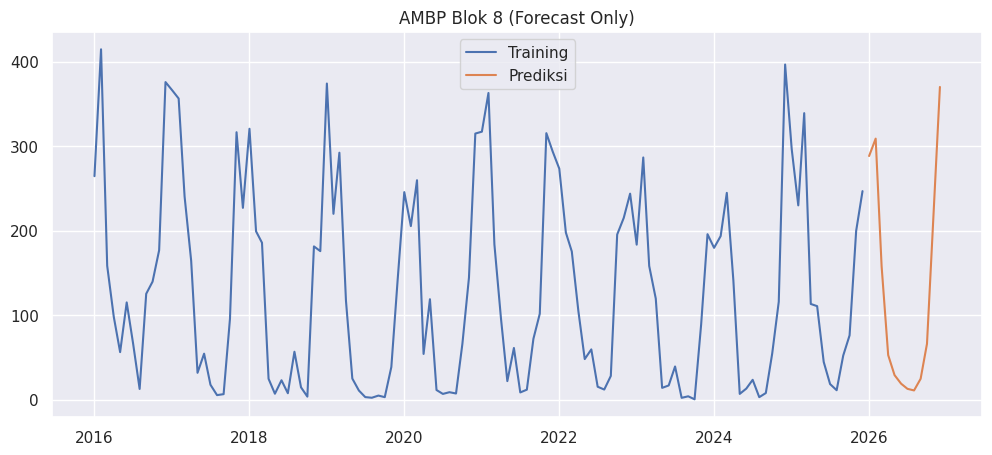

In [19]:
# ===============================
# AMBP BLOCK-BASED (FULL LOOP - LOG TRANSFORM)
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ambp_results = []

lag = 12

# ===============================
# FUNGSI LAG (SAMA PERSIS)
# ===============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

# ===============================
# LOOP BLOCK-BASED
# ===============================
for i, (train_start, train_end, test_start, test_end) in enumerate(blocks):

    print(f"\n===============================")
    print(f"AMBP BLOK {i+1}")
    print(f"===============================")

    # ===============================
    # DATA
    # ===============================
    train_block = rain_series[train_start:train_end]
    actual = rain_series[test_start:test_end]

    print("Training size:", train_block.shape)
    print("Actual size:", actual.shape)

    # ===============================
    # LOG TRANSFORM (WAJIB)
    # ===============================
    train_log = np.log1p(train_block)

    # ===============================
    # NORMALISASI
    # ===============================
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_log.values.reshape(-1,1))

    # ===============================
    # LAG
    # ===============================
    X_train, y_train = create_lagged_data(train_scaled, lag)

    print("X shape:", X_train.shape)
    print("y shape:", y_train.shape)

    # ===============================
    # MODEL
    # ===============================
    model = MLPRegressor(
        hidden_layer_sizes=(20,10),
        activation='relu',
        solver='adam',
        max_iter=2000,
        early_stopping=True,
        random_state=42
    )

    model.fit(X_train, y_train.ravel())

    print("\nTraining selesai")
    print("Iterations:", model.n_iter_)

    # ===============================
    # ERROR TRAINING
    # ===============================
    train_pred_scaled = model.predict(X_train)

    train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
    train_actual = scaler.inverse_transform(y_train)

    train_pred = np.expm1(train_pred)
    train_actual = np.expm1(train_actual)

    mae_train = mean_absolute_error(train_actual, train_pred)
    mse_train = mean_squared_error(train_actual, train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(train_actual, train_pred)

    print("\n=== ERROR TRAINING BLOK ===")
    print("MAE :", mae_train)
    print("MSE :", mse_train)
    print("RMSE:", rmse_train)
    print("R2  :", r2_train)

    # ===============================
    # PREDIKSI ITERATIF (12 BULAN)
    # ===============================
    last_window = train_scaled[-lag:]
    current_input = last_window.copy()

    forecast_scaled = []

    for _ in range(12):
        pred = model.predict(current_input.reshape(1,-1))
        forecast_scaled.append(pred[0])
        current_input = np.append(current_input[1:], pred)

    forecast = scaler.inverse_transform(
        np.array(forecast_scaled).reshape(-1,1)
    )

    forecast = np.expm1(forecast).flatten()
    forecast = np.maximum(forecast, 0)

    # ===============================
    # HANDLE BLOK 8
    # ===============================
    if len(actual) == 0:

        print("\n=== BLOK TANPA DATA AKTUAL (FORECAST ONLY) ===")

        forecast_index = pd.date_range(start=test_start, periods=12, freq='MS')

        forecast_series = pd.Series(
            forecast,
            index=forecast_index
        )

        sarima_forecast_2026 = forecast.copy()

        print("\n=== HASIL PREDIKSI ===")
        print(forecast_series)

        ambp_results.append({
            "block": i+1,
            "MAE_Train": mae_train,
            "MSE_Train": mse_train,
            "RMSE_Train": rmse_train,
            "R2_Train": r2_train,
            "MAE_Pred": None,
            "MSE_Pred": None,
            "RMSE_Pred": None,
            "R2_Pred": None
        })

        plt.figure(figsize=(12,5))
        plt.plot(train_block.index, train_block, label="Training")
        plt.plot(forecast_series.index, forecast_series, label="Prediksi")
        plt.title(f"AMBP Blok {i+1} (Forecast Only)")
        plt.legend()
        plt.show()

    else:
        forecast_series = pd.Series(
            forecast,
            index=actual.index
        )

        print("\n=== HASIL PREDIKSI 12 BULAN ===")
        print(forecast_series)

        # ===============================
        # AKTUAL VS PREDIKSI
        # ===============================
        comparison = pd.DataFrame({
            'AKTUAL': actual,
            'PREDIKSI': forecast_series
        })

        print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
        print(comparison)

        # ===============================
        # ERROR PREDIKSI
        # ===============================
        mae_pred = mean_absolute_error(actual, forecast_series)
        mse_pred = mean_squared_error(actual, forecast_series)
        rmse_pred = np.sqrt(mse_pred)
        r2_pred = r2_score(actual, forecast_series)

        print("\n=== ERROR PREDIKSI ===")
        print("MAE :", mae_pred)
        print("MSE :", mse_pred)
        print("RMSE:", rmse_pred)
        print("R2  :", r2_pred)

        ambp_results.append({
            "block": i+1,
            "MAE_Train": mae_train,
            "MSE_Train": mse_train,
            "RMSE_Train": rmse_train,
            "R2_Train": r2_train,
            "MAE_Pred": mae_pred,
            "MSE_Pred": mse_pred,
            "RMSE_Pred": rmse_pred,
            "R2_Pred": r2_pred
        })

        # ===============================
        # PLOT
        # ===============================
        plt.figure(figsize=(12,5))
        plt.plot(train_block.index, train_block, label="Training")
        plt.plot(actual.index, actual, label="Aktual")
        plt.plot(forecast_series.index, forecast_series, label="Prediksi")

        plt.title(f"AMBP Blok {i+1}")
        plt.legend()
        plt.show()

# DI BAWAH INI ADALAH PLOT PLOT UNTUK KEBUTUHAN GAMBAR DI DRAFT

# PERBANDINGAN MODEL (RATA-RATA TRAINING & PREDIKSI)

In [20]:
# ===============================
# KONVERSI KE DATAFRAME
# ===============================
sarima_df = pd.DataFrame(sarima_results)
ambp_df = pd.DataFrame(ambp_results)

# ===============================
# HAPUS BLOK TANPA EVALUASI (blok 8)
# ===============================
sarima_eval = sarima_df.dropna()
ambp_eval = ambp_df.dropna()

# ===============================
# RATA-RATA TRAINING
# ===============================
sarima_train_avg = sarima_eval[[
    'MAE_Train','MSE_Train','RMSE_Train','R2_Train'
]].mean()

ambp_train_avg = ambp_eval[[
    'MAE_Train','MSE_Train','RMSE_Train','R2_Train'
]].mean()

# ===============================
# RATA-RATA PREDIKSI
# ===============================
sarima_pred_avg = sarima_eval[[
    'MAE_Pred','MSE_Pred','RMSE_Pred','R2_Pred'
]].mean()

ambp_pred_avg = ambp_eval[[
    'MAE_Pred','MSE_Pred','RMSE_Pred','R2_Pred'
]].mean()

In [21]:
print("\n=== PERBANDINGAN MODEL (RATA-RATA TRAINING) ===")

train_table = pd.DataFrame({
    'AMBP': ambp_train_avg.values,
    'SARIMA': sarima_train_avg.values
}, index=['MAE','MSE','RMSE','R2'])

print(train_table.round(4))


=== PERBANDINGAN MODEL (RATA-RATA TRAINING) ===
           AMBP     SARIMA
MAE     44.8179    52.3290
MSE   4687.8366  6355.9479
RMSE    67.6001    79.4075
R2       0.5702     0.4263


In [22]:
print("\n=== PERBANDINGAN MODEL (RATA-RATA PREDIKSI) ===")

pred_table = pd.DataFrame({
    'AMBP': ambp_pred_avg.values,
    'SARIMA': sarima_pred_avg.values
}, index=['MAE','MSE','RMSE','R2'])

print(pred_table.round(4))


=== PERBANDINGAN MODEL (RATA-RATA PREDIKSI) ===
           AMBP     SARIMA
MAE     63.8426    43.1026
MSE   7955.2791  3766.7530
RMSE    83.2116    58.0654
R2       0.3072     0.6903


In [23]:
# ===============================
# PENENTUAN MODEL TERBAIK (FIX)
# ===============================
score_ambp = (
    ambp_pred_avg['RMSE_Pred'] +
    ambp_pred_avg['MAE_Pred'] -
    ambp_pred_avg['R2_Pred']
)

score_sarima = (
    sarima_pred_avg['RMSE_Pred'] +
    sarima_pred_avg['MAE_Pred'] -
    sarima_pred_avg['R2_Pred']
)

best_model = "SARIMA" if score_sarima < score_ambp else "AMBP"

print("\n=== KESIMPULAN ===")
print("Model terbaik:", best_model)


=== KESIMPULAN ===
Model terbaik: SARIMA


# Jangan pakai MAPE untuk data hujan
→ karena banyak nilai kecil (bikin error jadi besar)

Bandingkan antar model

AMBP
SARIMA

👉 pilih yang:
*   MAE lebih kecil
*   RMSE lebih kecil
*   R² lebih tinggi

Contoh simpulan:

“Model SARIMA (2,0,1)(1,1,1,12) dipilih karena memiliki error lebih rendah dan R² lebih tinggi dibanding model lainnya.”

In [24]:
print(pd.DataFrame(sarima_results))
print(pd.DataFrame(ambp_results))

   block  MAE_Train    MSE_Train  RMSE_Train  MAPE_Train  R2_Train   MAE_Pred  \
0      1  59.499823  7952.562037   89.177139  533.727757  0.311588  43.485141   
1      2  48.482722  6351.070163   79.693602  227.316546  0.392880  26.913886   
2      3  43.128440  5096.078314   71.386822  108.186378  0.482400  26.737742   
3      4  49.083475  4973.856561   70.525574  233.842808  0.502362  36.512445   
4      5  49.870748  5437.003776   73.736041  191.429335  0.479359  43.949261   
5      6  57.509442  7114.455815   84.347234  499.441771  0.381500  72.792394   
6      7  58.728393  7566.608731   86.986256  139.992347  0.433852  51.327426   
7      8  61.145120  8065.871088   89.810195  305.407569  0.399921        NaN   

      MSE_Pred  RMSE_Pred    MAPE_Pred   R2_Pred  
0  3815.145047  61.766860   501.582611  0.698995  
1  1320.611508  36.340219    53.942450  0.843807  
2  1104.632541  33.236013   137.026899  0.799608  
3  2386.971647  48.856644   441.560186  0.787970  
4  3492.749541 

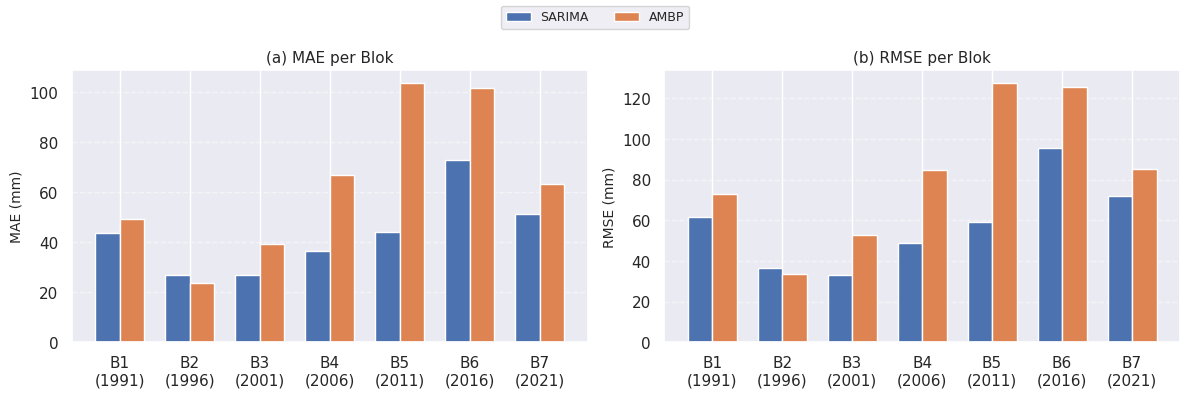

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# DATAFRAME
# ===============================
sarima_df = pd.DataFrame(sarima_results)
ambp_df = pd.DataFrame(ambp_results)

# ===============================
# DROP BLOK TANPA EVALUASI (blok 8)
# ===============================
sarima_df = sarima_df.dropna()
ambp_df = ambp_df.dropna()

# ===============================
# LABEL BLOK + TAHUN
# ===============================
labels = ['B1\n(1991)','B2\n(1996)','B3\n(2001)',
          'B4\n(2006)','B5\n(2011)','B6\n(2016)','B7\n(2021)']

x = np.arange(len(labels))
width = 0.35

# ===============================
# STYLE JURNAL (MINIMALIS)
# ===============================
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9
})

# ===============================
# FIGURE
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ===============================
# MAE
# ===============================
axes[0].bar(x - width/2, sarima_df['MAE_Pred'], width, label='SARIMA')
axes[0].bar(x + width/2, ambp_df['MAE_Pred'], width, label='AMBP')

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('MAE (mm)')
axes[0].set_title('(a) MAE per Blok')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ===============================
# RMSE
# ===============================
axes[1].bar(x - width/2, sarima_df['RMSE_Pred'], width, label='SARIMA')
axes[1].bar(x + width/2, ambp_df['RMSE_Pred'], width, label='AMBP')

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('RMSE (mm)')
axes[1].set_title('(b) RMSE per Blok')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# ===============================
# LEGEND (GLOBAL)
# ===============================
fig.legend(['SARIMA','AMBP'], loc='upper center', ncol=2)

# ===============================
# LAYOUT
# ===============================
plt.tight_layout(rect=[0,0,1,0.92])

# ===============================
# SAVE (WAJIB UNTUK JURNAL)
# ===============================
plt.savefig("perbandingan_sarima_ambp.png", dpi=300, bbox_inches='tight')

plt.show()

# CODE VISUALISASI R²

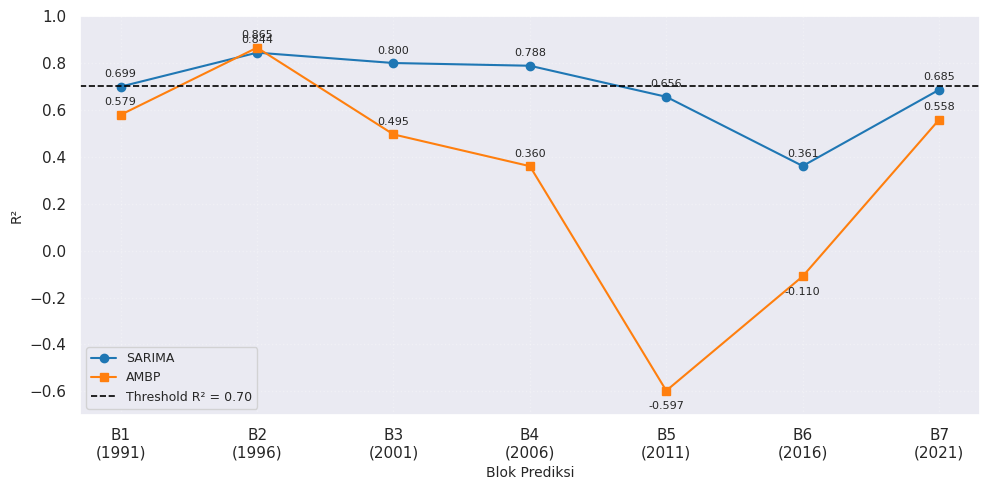

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# DATA
# ===============================
sarima_df = pd.DataFrame(sarima_results).dropna()
ambp_df   = pd.DataFrame(ambp_results).dropna()

labels = ['B1\n(1991)','B2\n(1996)','B3\n(2001)',
          'B4\n(2006)','B5\n(2011)','B6\n(2016)','B7\n(2021)']

x = np.arange(len(labels))

# ===============================
# FIGURE
# ===============================
plt.figure(figsize=(10,5))

# ===============================
# LINE PLOT (✔ WARNA DIPERBAIKI)
# ===============================
plt.plot(x, sarima_df['R2_Pred'], marker='o',
         color='#1f77b4', label='SARIMA')   # biru clean

plt.plot(x, ambp_df['R2_Pred'], marker='s',
         color='#ff7f0e', label='AMBP')     # orange clean

# ===============================
# LABEL TITIK (✔ OFFSET KONSISTEN)
# ===============================
for i, val in enumerate(sarima_df['R2_Pred']):
    offset = 0.04 if val >= 0 else -0.08
    plt.text(i, val + offset, f"{val:.3f}", ha='center', fontsize=8)

for i, val in enumerate(ambp_df['R2_Pred']):
    offset = 0.04 if val >= 0 else -0.08
    plt.text(i, val + offset, f"{val:.3f}", ha='center', fontsize=8)

# ===============================
# THRESHOLD (✔ DIPERTEGAS)
# ===============================
plt.axhline(y=0.70, linestyle='--', linewidth=1.2, color='black',
            label='Threshold R² = 0.70')

# ===============================
# AXIS (✔ SUPPORT NILAI NEGATIF)
# ===============================
plt.xticks(x, labels)
plt.ylabel('R²')
plt.xlabel('Blok Prediksi')
plt.ylim(-0.7, 1)   # ← INI PENTING (biar R2 negatif kelihatan)

# ===============================
# GRID (✔ DIPERHALUS)
# ===============================
plt.grid(True, linestyle=':', alpha=0.3)

# ===============================
# LEGEND
# ===============================
plt.legend()

# ===============================
# SAVE (WAJIB JURNAL)
# ===============================
plt.tight_layout()
plt.savefig("r2_per_block_final.png", dpi=300, bbox_inches='tight')

plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'

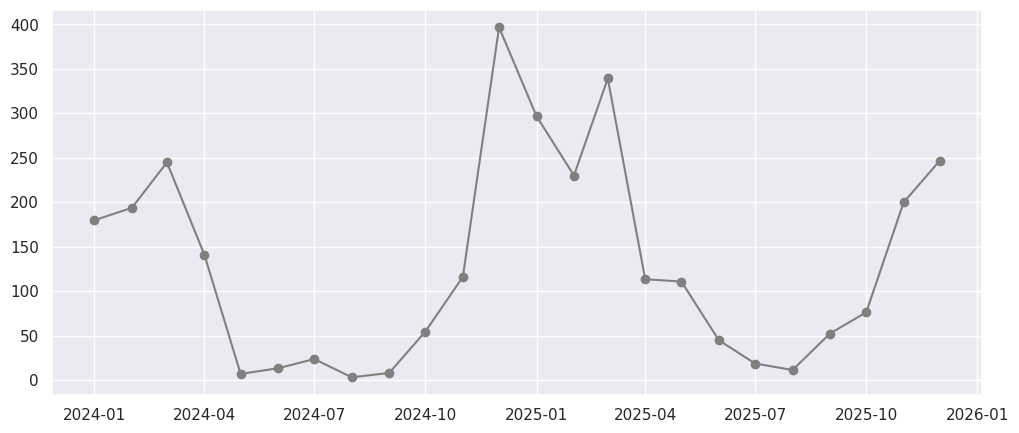

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# ===============================
# DATA AKTUAL (2 TAHUN TERAKHIR)
# ===============================
actual_2024_2025 = rain_series['2024-01-01':'2025-12-01']

# ===============================
# PREDIKSI (PASTIKAN INI SUDAH DISIMPAN DARI BLOK 8)
# ===============================
# sarima_forecast_2026
# ambp_forecast_2026

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

# -------------------------------
# AKTUAL
# -------------------------------
plt.plot(actual_2024_2025.index,
         actual_2024_2025,
         marker='o',
         color='gray',
         label='Data Aktual (2024–2025)')

# -------------------------------
# SARIMA
# -------------------------------
plt.plot(sarima_forecast_2026.index,
         sarima_forecast_2026,
         marker='o',
         linestyle='--',
         color='#1f77b4',
         label='Prediksi SARIMA 2026')

# -------------------------------
# AMBP
# -------------------------------
plt.plot(ambp_forecast_2026.index,
         ambp_forecast_2026,
         marker='s',
         linestyle='--',
         color='#ff7f0e',
         label='Prediksi AMBP 2026')

# -------------------------------
# GARIS PEMISAH (2026)
# -------------------------------
plt.axvline(x=pd.Timestamp('2026-01-01'),
            linestyle='--',
            color='black')

# -------------------------------
# ANOTASI "Prediksi →"
# -------------------------------
plt.text(pd.Timestamp('2026-02-01'),
         plt.ylim()[1]*0.9,
         'Prediksi →',
         fontsize=10)

# -------------------------------
# AXIS
# -------------------------------
plt.xlabel('Bulan')
plt.ylabel('Curah Hujan (mm)')

# -------------------------------
# GRID
# -------------------------------
plt.grid(True, linestyle=':', alpha=0.3)

# -------------------------------
# LEGEND
# -------------------------------
plt.legend()

# -------------------------------
# SAVE (WAJIB JURNAL)
# -------------------------------
plt.tight_layout()
plt.savefig("prediksi_2026.png", dpi=300, bbox_inches='tight')

plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'

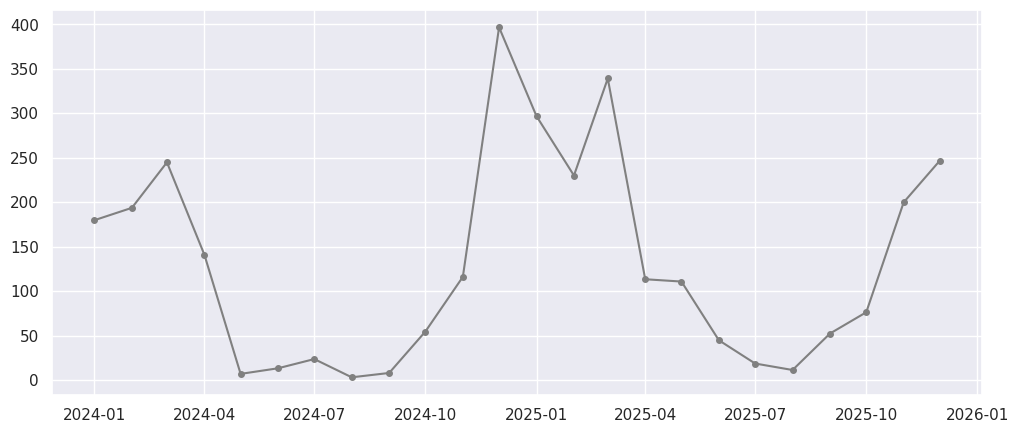

In [28]:
# ===============================
# PLOT FINAL (AKTUAL + PREDIKSI 2026)
# ===============================
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# DATA AKTUAL (2 TAHUN TERAKHIR)
# -------------------------------
actual_2024_2025 = rain_series['2024-01-01':'2025-12-01']

# Create date index for 2026 forecasts
forecast_2026_index = pd.date_range(start='2026-01-01', periods=12, freq='MS')

# Convert numpy arrays to pandas Series with the correct index
sarima_forecast_2026_series = pd.Series(sarima_forecast_2026, index=forecast_2026_index)
ambp_forecast_2026_series = pd.Series(ambp_forecast_2026, index=forecast_2026_index)


# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(12,5))

# AKTUAL
plt.plot(actual_2024_2025.index,
         actual_2024_2025,
         marker='o',
         markersize=4,
         color='gray',
         label='Actual Data (2024–2025)')

# SARIMA
plt.plot(sarima_forecast_2026_series.index,  # Use the Series
         sarima_forecast_2026_series,      # Use the Series
         marker='o',
         markersize=5,
         linestyle='--',
         color='#1f77b4',
         label='SARIMA Forecast 2026')

# AMBP
plt.plot(ambp_forecast_2026_series.index,    # Use the Series
         ambp_forecast_2026_series,        # Use the Series
         marker='s',
         markersize=5,
         linestyle='--',
         color='#ff7f0e',
         label='AMBP Forecast 2026')

# -------------------------------
# GARIS PEMBATAS (2026)
# -------------------------------
plt.axvline(x=pd.Timestamp('2026-01-01'),
            linestyle='--',
            linewidth=1.5,
            color='black')

# -------------------------------
# ANOTASI
# -------------------------------
plt.text(pd.Timestamp('2026-03-01'),
         380,
         'Forecast →',
         fontsize=10)

# -------------------------------
# AXIS
# -------------------------------
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.ylim(0, 420)   # FIX supaya tidak mepet atas

# -------------------------------
# GRID
# -------------------------------
plt.grid(True, linestyle=':', alpha=0.3)

# -------------------------------
# LEGEND
# -------------------------------
plt.legend()

# -------------------------------
# SAVE
# -------------------------------
plt.tight_layout()
plt.savefig("prediksi_2026_final.png", dpi=300, bbox_inches='tight')

plt.show()

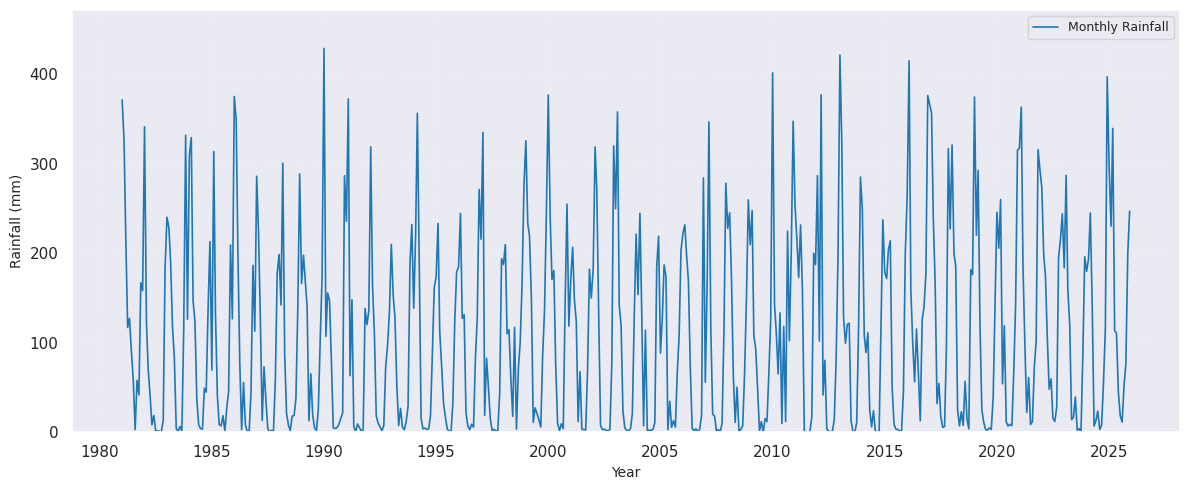

In [29]:
# ===============================
# VISUALISASI DATA HISTORIS (1981–2025)
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot data historis
plt.plot(rain_series.index,
         rain_series,
         color='#1f77b4',
         linewidth=1.2,
         label='Monthly Rainfall')

# ===============================
# AXIS
# ===============================
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')

# ===============================
# GRID (journal-friendly)
# ===============================
plt.grid(True, linestyle=':', alpha=0.3)

# ===============================
# LEGEND
# ===============================
plt.legend()

# ===============================
# LIMIT (opsional biar rapi)
# ===============================
plt.ylim(0, rain_series.max() * 1.1)

# ===============================
# SAVE (untuk jurnal)
# ===============================
plt.tight_layout()
plt.savefig("historical_rainfall_ntb.png", dpi=300, bbox_inches='tight')

plt.show()

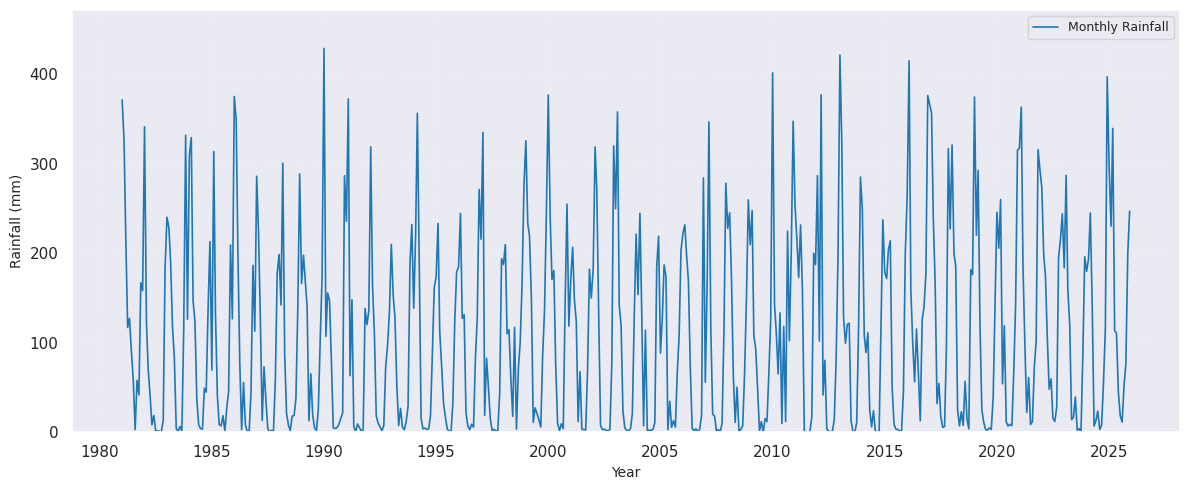

In [30]:
# ===============================
# VISUALISASI DATA HISTORIS (1981–2025)
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot data historis
plt.plot(rain_series.index,
         rain_series,
         color='#1f77b4',
         linewidth=1.2,
         label='Monthly Rainfall')

# ===============================
# AXIS
# ===============================
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')

# ===============================
# GRID (journal-friendly)
# ===============================
plt.grid(True, linestyle=':', alpha=0.3)

# ===============================
# LEGEND
# ===============================
plt.legend()

# ===============================
# LIMIT (opsional biar rapi)
# ===============================
plt.ylim(0, rain_series.max() * 1.1)

# ===============================
# SAVE (untuk jurnal)
# ===============================
plt.tight_layout()
plt.savefig("gambar_ntb.eps", format='eps', bbox_inches='tight')

plt.show()